# Importing Dataset

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

# Define the target directory in Google Drive where the files were saved
gdrive_folder_path = '/content/drive/MyDrive/yolo_dataset'

# Define paths for the zipped dataset and data.yaml in Google Drive
source_original_zip_gdrive_path = os.path.join(gdrive_folder_path, 'original_dataset.zip')
source_data_yaml_gdrive_path = os.path.join(gdrive_folder_path, 'data.yaml')

# Define destination paths in the Colab environment
destination_original_zip_local_path = 'original_dataset.zip'
destination_data_yaml_local_path = 'data.yaml'

# Check if the zip file exists in Google Drive before copying
if os.path.exists(source_original_zip_gdrive_path):
    # Copy the zipped dataset from Google Drive to the local Colab environment
    !cp "{source_original_zip_gdrive_path}" "{destination_original_zip_local_path}"
    print(f"'{destination_original_zip_local_path}' copied from Google Drive.")
else:
    print(f"Warning: '{source_original_zip_gdrive_path}' not found in Google Drive. Please ensure the dataset is saved there.")

# Copy the data.yaml file from Google Drive to the local Colab environment
!cp "{source_data_yaml_gdrive_path}" "{destination_data_yaml_local_path}"
print(f"'{destination_data_yaml_local_path}' copied from Google Drive.")

Mounted at /content/drive
'original_dataset.zip' copied from Google Drive.
'data.yaml' copied from Google Drive.


In [3]:
# Unzip the original_dataset.zip file, only if it exists locally
import os

zip_file_name = 'original_dataset.zip'
if os.path.exists(zip_file_name):
    !unzip -q {zip_file_name}
    print(f"'{zip_file_name}' unzipped successfully.")
else:
    print(f"Warning: '{zip_file_name}' not found locally. Skipping unzip operation.")

'original_dataset.zip' unzipped successfully.


making Train, Validation, Test Directories

In [4]:
import os
import json
import shutil
from tqdm import tqdm # for progress bars

# Define paths based on where original_dataset.zip was unzipped
base_dataset_path = 'dataset' # This is where original_dataset.zip unzips to
images_src_path = os.path.join(base_dataset_path, 'images')
annotations_file = os.path.join(base_dataset_path, 'annotations', 'annotations.json')
distribution_file = os.path.join(base_dataset_path, 'annotations', 'train_val_test_distribution_file.json')

yolo_dataset_path = 'dataset_yolo'

# Create YOLO format directories
for subset in ['train', 'val', 'test']:
    os.makedirs(os.path.join(yolo_dataset_path, 'images', subset), exist_ok=True)
    os.makedirs(os.path.join(yolo_dataset_path, 'labels', subset), exist_ok=True)

# Load annotations and distribution data
with open(annotations_file, 'r') as f:
    coco_data = json.load(f)

with open(distribution_file, 'r') as f:
    distribution_data = json.load(f)

# Create a mapping from image ID to image info (width, height, file_name)
image_id_to_info = {img['id']: {'width': img['width'], 'height': img['height'], 'file_name': img['file_name']} for img in coco_data['images']}

# Create a mapping from image file name to image ID
image_name_to_id = {img['file_name']: img['id'] for img in coco_data['images']}

# Create a mapping from category ID to category name
category_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}

# We want a single class 'litter' for YOLO training
class_names_yolo = ['litter']
class_name_to_id_yolo = {'litter': 0} # Map 'litter' to class_id 0

print(f"Found {len(class_names_yolo)} classes for YOLO: {class_names_yolo}")

# Process annotations for each subset
for subset_name, image_names in distribution_data.items():
    print(f"Processing {subset_name} set ({len(image_names)} images)...")
    for img_name in tqdm(image_names):
        img_id = image_name_to_id.get(img_name)
        if img_id is None:
            print(f"Warning: Image {img_name} not found in annotations. Skipping.")
            continue

        img_info = image_id_to_info[img_id]
        img_width = img_info['width']
        img_height = img_info['height']

        # Copy image to YOLO directory
        src_image_path = os.path.join(images_src_path, img_name)
        dst_image_path = os.path.join(yolo_dataset_path, 'images', subset_name, img_name)
        shutil.copy(src_image_path, dst_image_path)

        # Prepare YOLO label file
        label_filename = os.path.splitext(img_name)[0] + '.txt'
        label_filepath = os.path.join(yolo_dataset_path, 'labels', subset_name, label_filename)

        with open(label_filepath, 'w') as f_label:
            # Find all annotations for the current image
            image_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]

            for ann in image_annotations:
                # All original annotations are for 'rubbish', which we map to 'litter' (class_id 0)
                class_id_yolo = class_name_to_id_yolo['litter']

                # COCO bbox: [x_min, y_min, width, height]
                x_min, y_min, bbox_width, bbox_height = ann['bbox']

                # Convert to YOLO format: [x_center, y_center, width, height] normalized
                x_center = (x_min + bbox_width / 2) / img_width
                y_center = (y_min + bbox_height / 2) / img_height
                norm_width = bbox_width / img_width
                norm_height = bbox_height / img_height

                f_label.write(f"{class_id_yolo} {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}\n")

print("\nDataset conversion complete!")

# Create data.yaml file with the updated class name
data_yaml_content = f"""
path: ../{yolo_dataset_path}  # dataset root dir, relative to data.yaml
train: images/train    # train images (relative to 'path')
val: images/val      # val images (relative to 'path')
test: images/test    # test images (optional)

# Classes
nc: {len(class_names_yolo)}  # number of classes
names: {class_names_yolo} # class names
"""

with open('/content/data.yaml', 'w') as f: # Write to /content/data.yaml as specified by user
    f.write(data_yaml_content)

print("/content/data.yaml created and updated with 'litter' as the class name.")

# Re-load the model if it was not already loaded, though it should be from eQVLDXuA1ngt


Found 1 classes for YOLO: ['litter']
Processing train set (540 images)...


100%|██████████| 540/540 [00:19<00:00, 27.93it/s]


Processing val set (116 images)...


100%|██████████| 116/116 [00:04<00:00, 27.03it/s]


Processing test set (116 images)...


100%|██████████| 116/116 [00:06<00:00, 16.75it/s]


Dataset conversion complete!
/content/data.yaml created and updated with 'litter' as the class name.


# End-to-End Prediction and Location Heatmap Pipeline

First, ensure all necessary libraries are installed:

```python
!pip install -q ultralytics folium
```

This pipeline performs object detection on a given set of images and visualizes the detection locations on an interactive map. It requires:

1.  **A trained YOLO model:** The pipeline expects a path to a `.pt` file containing your trained YOLO model (e.g., `Yolo26x_litter.pt`).
2.  **Input Image Data:** A list of dictionaries, where each dictionary represents an image and includes:
    *   `'image_path'`: The full path to the image file (e.g., `/content/dataset_yolo/images/test/BATCH_d07_img_3010.jpg`).
    *   `'latitude'`: The geographical latitude of where the image was captured.
    *   `'longitude'`: The geographical longitude of where the image was captured.

The pipeline will first display a few original and predicted images, and then generate a Folium heatmap showing the aggregate locations of all detected objects.

In [5]:
!pip install -q ultralytics folium

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.2 MB/s eta 0:00:00


In [ ]:
import os
import folium
from folium.plugins import HeatMap
from IPython.display import Image, display, IFrame
from ultralytics import YOLO
import matplotlib.pyplot as plt

def run_prediction_pipeline(images_to_process_with_locations, model_path='/content/Yolo26x_litter.pt', num_images_to_display=3):
    """
    Runs an end-to-end pipeline for object detection, visualizes original and predicted images,
    and plots detected object locations on an interactive heatmap.

    Args:
        images_to_process_with_locations (list): A list of dictionaries, where each dictionary
                                                 contains 'image_path', 'latitude', and 'longitude'
                                                 for an image.
        model_path (str): Path to the trained YOLO model.
        num_images_to_display (int): The number of original/predicted image pairs to display.
    """
    print("--- Starting Object Detection and Mapping Pipeline ---")

    # Load the model
    try:
        model = YOLO(model_path)
        print(f"Model loaded successfully from {model_path}.")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        return

    heatmap_data = [] # To store [latitude, longitude, intensity] for heatmap

    for i, img_data in enumerate(images_to_process_with_locations):
        image_path = img_data['image_path']
        image_lat = img_data['latitude']
        image_lon = img_data['longitude']

        print(f"\nProcessing image {i+1}: {os.path.basename(image_path)}")
        print(f"  Coordinates: Latitude {image_lat}, Longitude {image_lon}")

        # Perform inference on the image
        # Use a unique name for each prediction run to avoid overwriting results
        run_name = f'pipeline_inference_run_{i}'
        results = model.predict(source=image_path, save=True, conf=0.5, name=run_name, project='runs/pipeline_detect')

        # Get the path to the predicted image
        predicted_image_dir = results[0].save_dir
        predicted_image_name = os.path.basename(image_path)
        predicted_image_full_path = os.path.join(predicted_image_dir, predicted_image_name)

        # Display original and predicted images side-by-side for the first few images
        if i < num_images_to_display:
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            fig.suptitle(f"Image: {os.path.basename(image_path)}", fontsize=16)

            # Original Image
            original_img = plt.imread(image_path)
            axes[0].imshow(original_img)
            axes[0].set_title("Original Image")
            axes[0].axis('off')

            # Predicted Image
            if os.path.exists(predicted_image_full_path):
                predicted_img = plt.imread(predicted_image_full_path)
                axes[1].imshow(predicted_img)
                axes[1].set_title("Predicted Image")
                axes[1].axis('off')
            else:
                axes[1].set_title("Predicted Image (Not Found)")
                axes[1].axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show()

        # Extract detections for heatmap
        if results and len(results[0].boxes) > 0:
            for box in results[0].boxes:
                # Each detection contributes a point to the heatmap at the image's central lat/lon
                heatmap_data.append([image_lat, image_lon, 1.0]) # 1.0 is intensity
            print(f"  Found {len(results[0].boxes)} detections for heatmap.")
        else:
            print("  No detections found for this image.")

    print("\n--- Generating Heatmap of Detections ---")

    if not heatmap_data:
        print("No detections were made, so no heatmap can be generated.")
        return

    # Calculate center for the map based on detected locations
    avg_lat = sum([d[0] for d in heatmap_data]) / len(heatmap_data)
    avg_lon = sum([d[1] for d in heatmap_data]) / len(heatmap_data)

    detection_map = folium.Map(location=[avg_lat, avg_lon], zoom_start=14)

    # Add heatmap layer
    HeatMap(heatmap_data).add_to(detection_map)

    print("\n--- Interactive Map of Detections ---")
    # Save to HTML and display via IFrame so the map renders in all environments
    # (local Jupyter, VS Code, Colab) without requiring notebook trust.
    map_path = 'detection_heatmap.html'
    detection_map.save(map_path)
    display(IFrame(map_path, width='100%', height=500))
    print(f"Map also saved to '{map_path}'.")
    print("Pipeline complete!")

--- Starting Object Detection and Mapping Pipeline ---
Model loaded successfully from /content/Yolo26x_litter.pt.

Processing image 1: BATCH_d07_img_3010.jpg
  Coordinates: Latitude 50.601, Longitude -3.429

image 1/1 /content/dataset_yolo/images/test/BATCH_d07_img_3010.jpg: 384x640 1 litter, 1845.3ms
Speed: 12.0ms preprocess, 1845.3ms inference, 7.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/runs/pipeline_detect/pipeline_inference_run_0


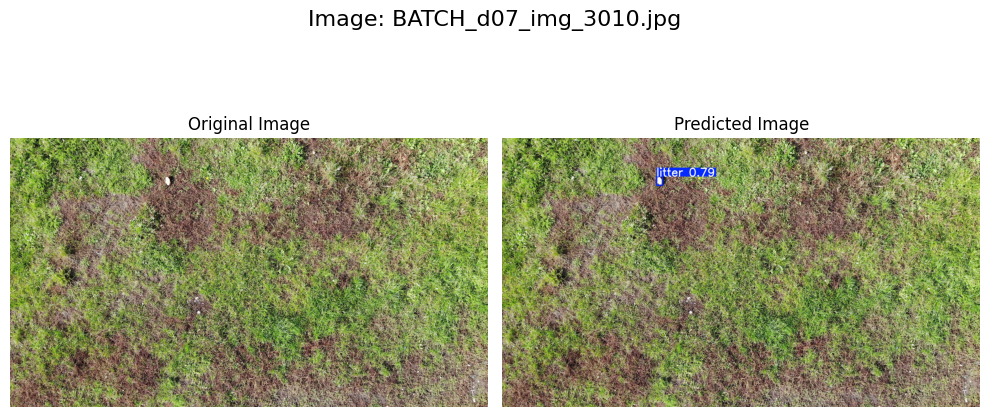

  Found 1 detections for heatmap.

Processing image 2: BATCH_s04_img_1080.jpg
  Coordinates: Latitude 50.602, Longitude -3.43

image 1/1 /content/dataset_yolo/images/test/BATCH_s04_img_1080.jpg: 288x640 3 litters, 1228.5ms
Speed: 2.0ms preprocess, 1228.5ms inference, 0.3ms postprocess per image at shape (1, 3, 288, 640)
Results saved to /content/runs/detect/runs/pipeline_detect/pipeline_inference_run_1


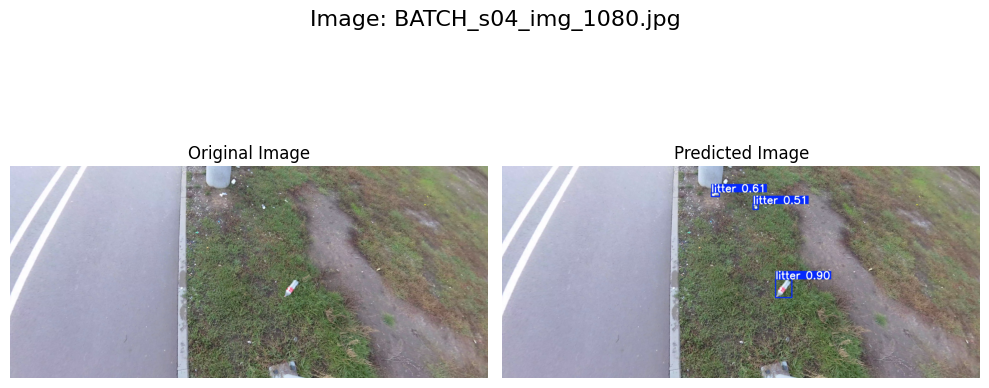

  Found 3 detections for heatmap.

Processing image 3: camera_img_1.jpg
  Coordinates: Latitude 50.6018, Longitude -3.4285

image 1/1 /content/dataset_yolo/images/test/camera_img_1.jpg: 640x480 (no detections), 2298.9ms
Speed: 3.2ms preprocess, 2298.9ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/runs/pipeline_detect/pipeline_inference_run_2


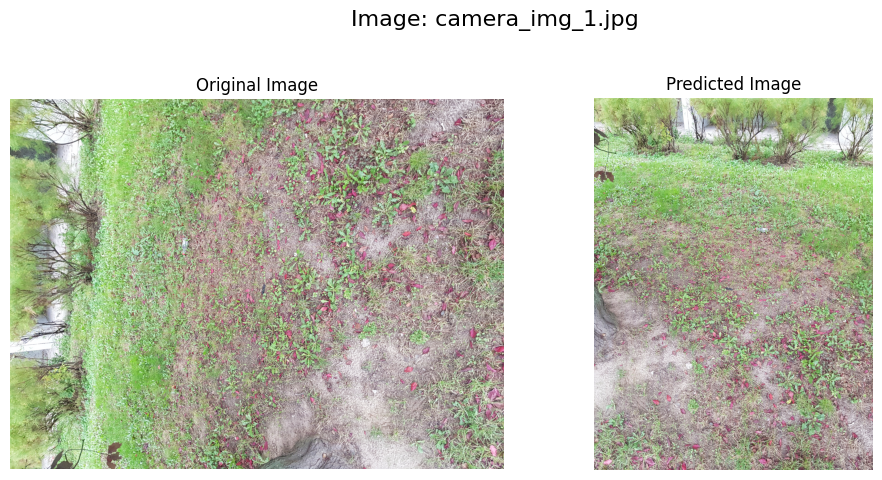

  No detections found for this image.

Processing image 4: BATCH_d06_img_3220.jpg
  Coordinates: Latitude 50.6005, Longitude -3.4295

image 1/1 /content/dataset_yolo/images/test/BATCH_d06_img_3220.jpg: 384x640 4 litters, 1613.4ms
Speed: 2.6ms preprocess, 1613.4ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/runs/pipeline_detect/pipeline_inference_run_3


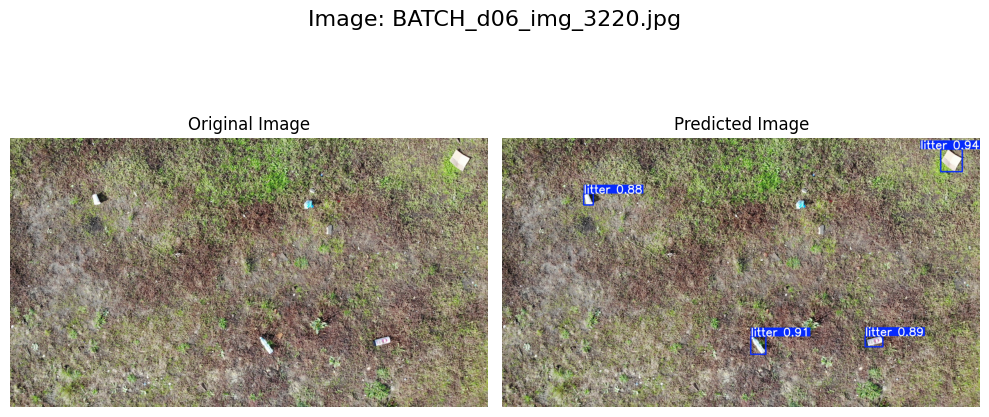

  Found 4 detections for heatmap.

--- Generating Heatmap of Detections ---

--- Interactive Map of Detections ---


Pipeline complete!


In [10]:
sample_images_with_coords = [
    {
        'image_path': '/content/dataset_yolo/images/test/BATCH_d07_img_3010.jpg',
        'latitude': 50.6010,
        'longitude': -3.4290
    },
    {
        'image_path': '/content/dataset_yolo/images/test/BATCH_s04_img_1080.jpg',
        'latitude': 50.6020,
        'longitude': -3.4300
    },
    {
        'image_path': '/content/dataset_yolo/images/test/camera_img_1.jpg',
        'latitude': 50.6018,
        'longitude': -3.4285
    },
    {
        'image_path': '/content/dataset_yolo/images/test/BATCH_d06_img_3220.jpg',
        'latitude': 50.6005,
        'longitude': -3.4295
    }
]

# Run the pipeline with the example data, using the fine-tuned model
run_prediction_pipeline(sample_images_with_coords, model_path='/content/Yolo26x_litter.pt', num_images_to_display=4)
